# NYC Bike Data — Dataset Description & Exploratory Analysis

This notebook documents and explores every dataset used in the project and underpins the
**technical report** in `docs/technical-report/`. It covers, in order of importance:

1. **Citi Bike trips** — the project's main data source (one monthly file, downloaded manually).
2. **Weather** — hourly NYC observations from the Open-Meteo archive (fetched live).
3. **Bike lanes** — NYC bike-route network from NYC OpenData (fetched live).
4. **Station metadata** — current Citi Bike stations from the Lyft GBFS feed (fetched live).

For each dataset we describe its **structure**, run **exploratory data analysis (EDA)**, and
assess **data quality**. See `src/notebooks/README.md` for how to obtain the ride data and run
this notebook. The exploration data is intentionally **not committed** to the repository.

## 0. Setup

In [28]:
import json
import re
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Where to find the manually-downloaded Citi Bike monthly CSV(s) (relative to this notebook).
DATA_DIR = Path("data")

# Data sources (mirrors src/ingestion/config.yaml and src/backend/config.yaml).
WEATHER_API_URL = "https://archive-api.open-meteo.com/v1/archive"
BIKE_ROUTES_URL = "https://data.cityofnewyork.us/api/views/mzxg-pwib/rows.csv?accessType=DOWNLOAD"
GBFS_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"
GBFS_STATUS_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_status.json"
NYC_LAT, NYC_LON = 40.7823234, -73.9654161

# Distance-feature constants (see src/ingestion/sources/distances.py).
EARTH_RADIUS_KM = 6371
STREET_CIRCUITY_FACTOR = 1.3

In [29]:
# Vectorised great-circle distance (km) scaled by the street-circuity factor,
# matching the production formula in src/ingestion/sources/distances.py.
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c * STREET_CIRCUITY_FACTOR

## 1. Citi Bike Trip Data

The core dataset. Citi Bike publishes one CSV per month, each row a single trip, available from
the [system-data page](https://www.citibikenyc.com/system-data). Download one month and place the
extracted CSV in the `data/` folder next to this notebook (see `README.md`).

In [30]:
# Newer files (2020+) and the legacy (pre-2020) schema use different column names.
# This map normalises the legacy columns to the modern schema so the rest of the
# notebook works regardless of which month was downloaded.
LEGACY_RENAME = {
    "starttime": "started_at",
    "stoptime": "ended_at",
    "start station name": "start_station_name",
    "start station id": "start_station_id",
    "end station name": "end_station_name",
    "end station id": "end_station_id",
    "start station latitude": "start_lat",
    "start station longitude": "start_lng",
    "end station latitude": "end_lat",
    "end station longitude": "end_lng",
}

def load_rides(data_dir: Path):
    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {data_dir.resolve()}. Download a Citi Bike monthly "
            "trip file, extract it, and place the CSV here. See src/notebooks/README.md."
        )
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)

    # Columns unique to the legacy schema — kept track of for the data-quality section.
    legacy_cols = [c for c in ["gender", "birth year", "bikeid", "tripduration", "usertype"]
                   if c in df.columns]
    is_legacy = "rideable_type" not in df.columns
    if is_legacy:
        df = df.rename(columns=LEGACY_RENAME)
        if "usertype" in df.columns:
            df["member_casual"] = df["usertype"].map(
                {"Subscriber": "member", "Customer": "casual"}
            ).fillna(df["usertype"])
        df["rideable_type"] = pd.NA          # absent before the e-bike rollout
        if "ride_id" not in df.columns:
            df["ride_id"] = df.index.astype(str)

    # Recent months carry fractional seconds (e.g. "...05.732"); ISO8601 parses both
    # whole- and fractional-second timestamps. "mixed" is the fallback for older layouts.
    for col in ["started_at", "ended_at"]:
        try:
            df[col] = pd.to_datetime(df[col], format="ISO8601")
        except (ValueError, TypeError):
            df[col] = pd.to_datetime(df[col], format="mixed")
    return df, {"files": [f.name for f in csv_files], "is_legacy": is_legacy,
                "legacy_cols": legacy_cols}

df, meta = load_rides(DATA_DIR)
print("Loaded files :", meta["files"])
print("Schema       :", "legacy (pre-2020)" if meta["is_legacy"] else "modern (2020+)")
print("Shape        :", df.shape)
df.head()

Loaded files : ['202605-citibike-tripdata_1.csv', '202605-citibike-tripdata_2.csv', '202605-citibike-tripdata_3.csv', '202605-citibike-tripdata_4.csv', '202605-citibike-tripdata_5.csv']
Schema       : modern (2020+)
Shape        : (4694878, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,31B4FB00D1807409,electric_bike,2026-05-01 15:25:05.732,2026-05-01 15:31:03.489,E 40 St & 5 Ave,6474.11,1 Ave & E 44 St,6379.03,40.752062,-73.981632,40.750020,-73.969053,member
1,B1BEE9F97DFBBCBF,classic_bike,2026-05-14 16:38:38.371,2026-05-14 16:53:26.309,8 Ave & W 24 St,6224.06,8 Ave & W 49 St,6747.07,40.745911,-73.998071,40.761712,-73.986551,member
2,64E0244C044F4E7A,electric_bike,2026-05-06 15:06:11.883,2026-05-06 15:15:57.544,Lafayette Ave & Franklin Ave,4528.03,Grove St & Broadway,4526.01,40.689271,-73.957324,40.690470,-73.923511,member
3,80BCDF15BAD45A74,electric_bike,2026-05-08 18:43:39.707,2026-05-08 18:48:02.677,Franklin Ave & Quincy St,4410.02,Monroe St & Tompkins Ave,4434.06,40.686360,-73.956780,40.686203,-73.944694,member
4,05C664BB4621F274,classic_bike,2026-05-11 22:49:39.188,2026-05-11 23:05:14.517,DeKalb Ave & Hudson Ave,4513.06,Pacific St & Classon Ave,4148.07,40.689888,-73.981013,40.679194,-73.958790,member


### 1.1 Structure

In [31]:
df.info()

print("\nUnique rideable_type :", df["rideable_type"].dropna().unique().tolist())
print("Unique member_casual :", df["member_casual"].dropna().unique().tolist())

unique_stations = pd.concat([df["start_station_name"], df["end_station_name"]]).nunique()
print(f"Unique stations      : {unique_stations}")
print(f"Date range           : {df['started_at'].min()} -> {df['started_at'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 4694878 entries, 0 to 4694877
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      str           
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       str           
dtypes: datetime64[us](2), float64(4), str(7)
memory usage: 465.6 MB

Unique rideable_type : ['electric_bike', 'classic_bike']
Unique member_casual : ['member', 'casual']
Unique stations      : 2290
Date range           : 2026-04-30 00:54:03.269000 -> 2026-05-31 23:58:10.888000


The original files contain a trip identifier, the bike type (`classic_bike` / `electric_bike`),
start/end timestamps, the start/end station names, ids and coordinates, and the user type
(`member` vs `casual`). We derive additional features below.

### 1.2 Trip Duration

Ride length (minutes) summary:
mean        13.51
median       9.46
min          1.00
max       1499.97
std         27.70
Name: ride_length_s, dtype: float64

Rides with negative duration : 0
Rides longer than 4 hours    : 3827


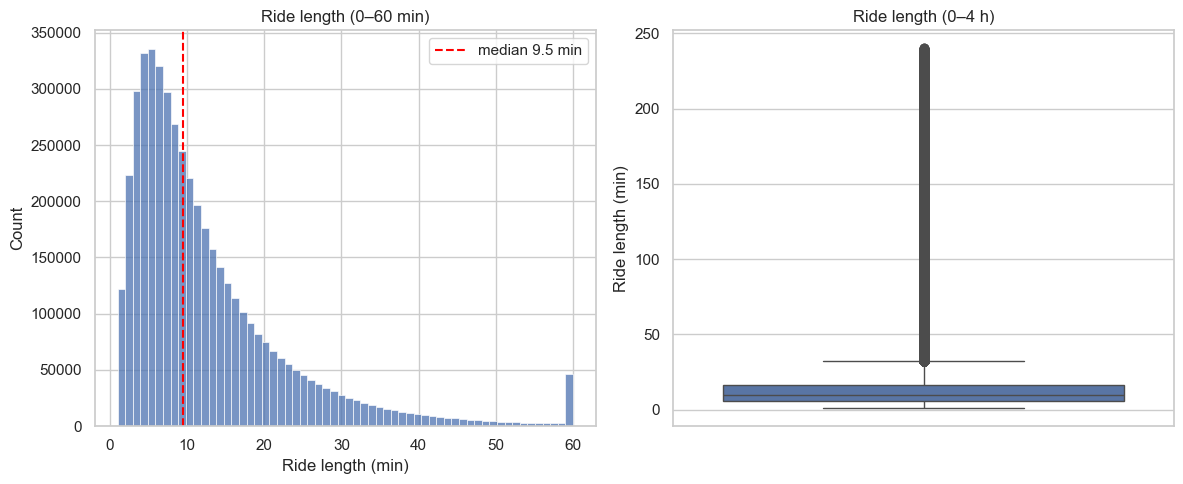

In [32]:
df["ride_length_s"] = (df["ended_at"] - df["started_at"]).dt.total_seconds()
df["ride_length_min"] = df["ride_length_s"] / 60

print("Ride length (minutes) summary:")
print((df["ride_length_s"] / 60).agg(["mean", "median", "min", "max", "std"]).round(2))

negative = (df["ride_length_s"] < 0).sum()
long_rides = (df["ride_length_s"] > 4 * 3600).sum()
print(f"\nRides with negative duration : {negative}")
print(f"Rides longer than 4 hours    : {long_rides}")

# Keep only the plausible range (0 to 4 h); the negative and very long rides would
# otherwise flatten the plot and hide where the trips actually are.
valid = df[(df["ride_length_s"] >= 0) & (df["ride_length_s"] <= 4 * 3600)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: histogram zoomed to the first hour, where almost all trips fall.
sns.histplot(valid["ride_length_min"].clip(upper=60), bins=60, ax=axes[0])
axes[0].axvline(valid["ride_length_min"].median(), color="red", ls="--",
                label=f"median {valid['ride_length_min'].median():.1f} min")
axes[0].set(title="Ride length (0–60 min)", xlabel="Ride length (min)")
axes[0].legend()
# Right: boxplot over the full plausible range shows the spread and the long upper tail.
sns.boxplot(y="ride_length_min", data=valid, ax=axes[1])
axes[1].set(title="Ride length (0–4 h)", ylabel="Ride length (min)")
plt.tight_layout()
plt.show()

Ride length is strongly **right-skewed**: most trips last only a few to ~20 minutes (left,
zoomed to the first hour), with a thin tail stretching to much longer rides. In the boxplot
(right) this skew is why the box — the middle 50% of trips — sits low while long rides appear as
points above the upper whisker; that is the expected shape of the data, not an error. Two
anomalies are excluded from both views: a few **negative** durations (the trip ends before it
starts — clock/data glitches) and rides over **4 hours**, which are far more likely a bike that
was never docked correctly than a genuine 4-hour trip.

### 1.3 Trip Distance

Trip distance (km) summary:
mean       2.701486
median     2.040331
min        0.000000
max       33.965615
std        2.274566
Name: trip_distance_km, dtype: float64


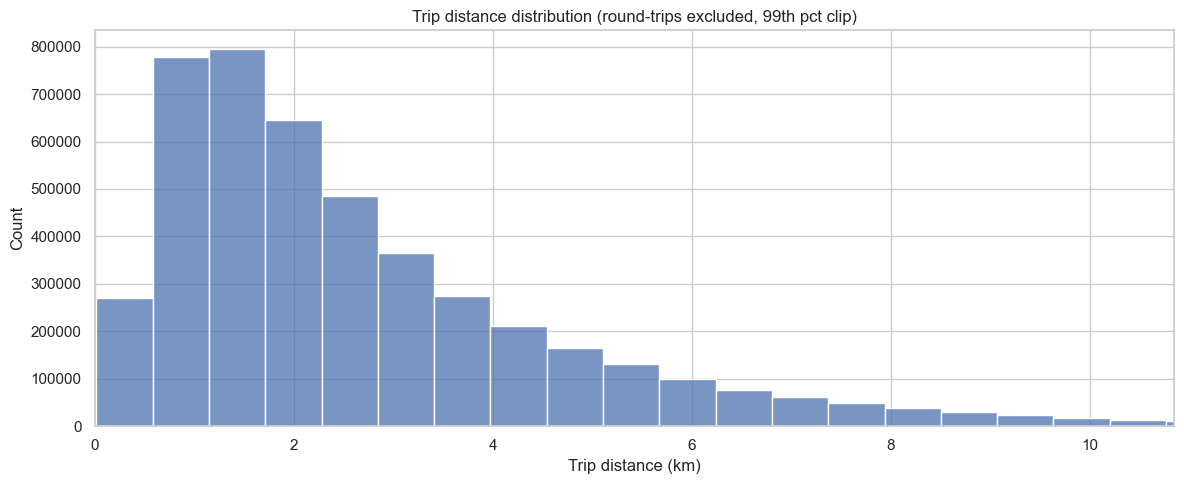

In [33]:
# Straight-line distance between start and end stations, scaled by the circuity factor
# to approximate the real travelled distance (production precomputes this per station pair
# and joins it onto rides; here we compute it directly from coordinates).
df["trip_distance_km"] = haversine_km(
    df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"]
)

print("Trip distance (km) summary:")
print(df["trip_distance_km"].agg(["mean", "median", "min", "max", "std"]))

# Round-trips (same start/end station) have ~0 straight-line distance; exclude for the plot.
plt.figure(figsize=(12, 5))
sns.histplot(df.loc[df["trip_distance_km"] > 0, "trip_distance_km"], bins=60)
plt.xlim(0, df["trip_distance_km"].quantile(0.99))
plt.xlabel("Trip distance (km)")
plt.title("Trip distance distribution (round-trips excluded, 99th pct clip)")
plt.tight_layout()
plt.show()

This is the **straight-line** distance between the start and end stations, scaled by a 1.3
circuity factor to approximate the real on-street path. Trips reported as **0 km** are *round
trips* that begin and end at the **same station**, so there is no station-to-station distance. This need to be considered when interpreting the distance distribution and computing statistics based on distance (e.g., average distance per trip, average speed).

### 1.4 Bike Type and User Type

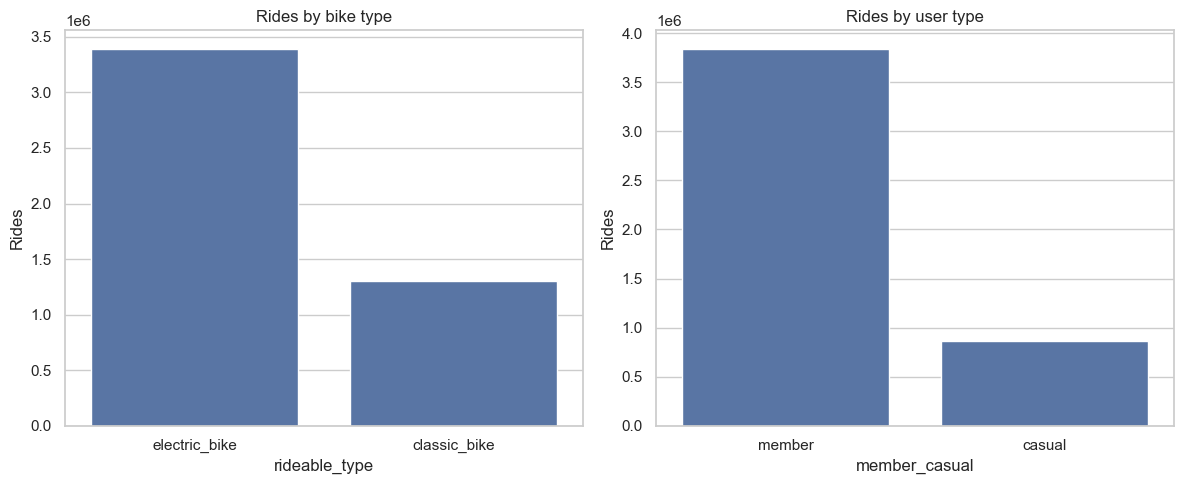

Avg ride length (min) by bike type:
rideable_type
classic_bike     14.5
electric_bike    13.1
Name: ride_length_min, dtype: float64

Avg ride length (min) by user type:
member_casual
casual    20.2
member    12.0
Name: ride_length_min, dtype: float64


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rideable = df["rideable_type"].value_counts(dropna=False)
sns.barplot(x=rideable.index.astype(str), y=rideable.values, ax=axes[0])
axes[0].set(title="Rides by bike type", xlabel="rideable_type", ylabel="Rides")

member = df["member_casual"].value_counts(dropna=False)
sns.barplot(x=member.index.astype(str), y=member.values, ax=axes[1])
axes[1].set(title="Rides by user type", xlabel="member_casual", ylabel="Rides")
plt.tight_layout()
plt.show()

print("Avg ride length (min) by bike type:")
print((df.groupby("rideable_type", dropna=False)["ride_length_min"].mean()).round(1))
print("\nAvg ride length (min) by user type:")
print((df.groupby("member_casual", dropna=False)["ride_length_min"].mean()).round(1))

Two patterns are typical of Citi Bike data: **members** make the large majority of trips (commuter
use), while **casual** riders, though fewer, take **longer** trips on average (leisure use). The
bike-type split shows the share of classic vs. electric bikes in the loaded month.

### 1.5 Temporal Patterns

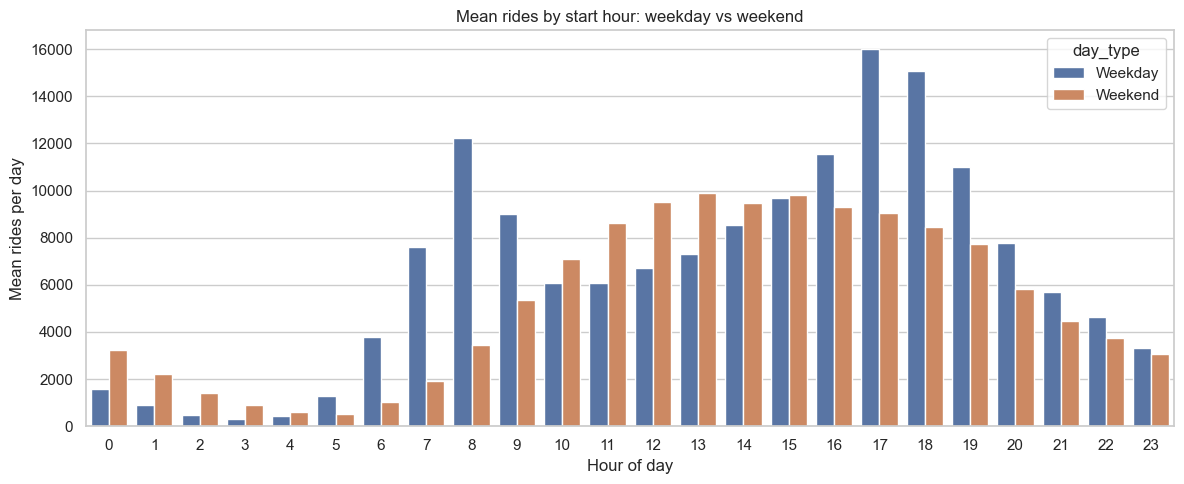

In [35]:
df["start_hour"] = df["started_at"].dt.hour
df["day_of_week"] = df["started_at"].dt.day_name()
df["date"] = df["started_at"].dt.date
df["day_type"] = np.where(
    df["started_at"].dt.weekday < 5, "Weekday", "Weekend"
)

# Mean rides per hour, separating weekdays from weekends.
hourly = (
    df.groupby(["date", "start_hour", "day_type"]).size().reset_index(name="rides")
)
mean_rides = hourly.groupby(["start_hour", "day_type"])["rides"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="start_hour", y="rides", hue="day_type", data=mean_rides)
plt.xlabel("Hour of day")
plt.ylabel("Mean rides per day")
plt.title("Mean rides by start hour: weekday vs weekend")
plt.tight_layout()
plt.show()

Weekdays show the classic bimodal commuting pattern — peaks around 8 AM and 5–6 PM — while
weekends follow a single midday hump consistent with leisure use.

### 1.6 Spatial Patterns

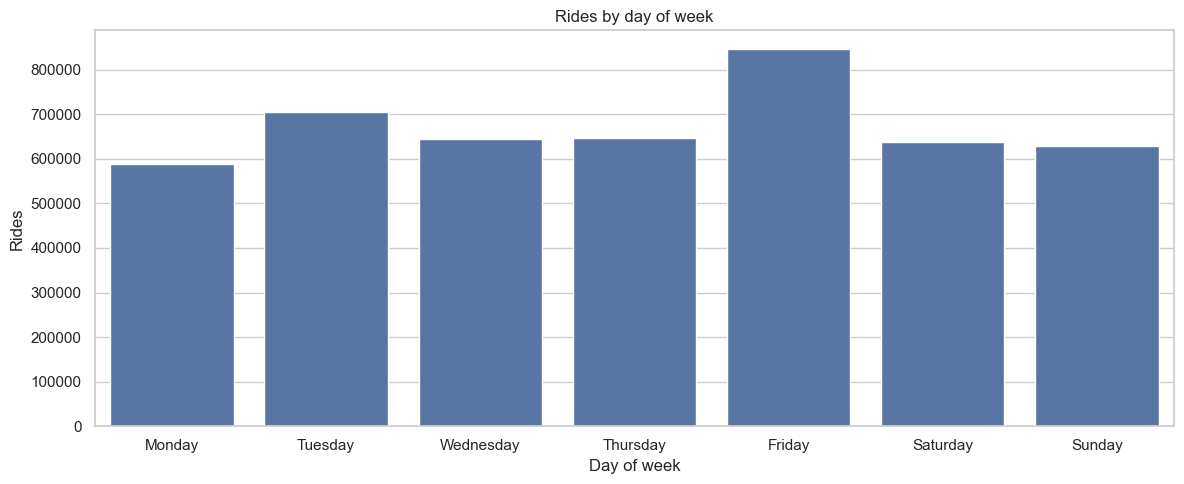

Top 10 start stations:
start_station_name
W 21 St & 6 Ave               16591
Cooper Square & Astor Pl      16281
Pier 61 at Chelsea Piers      16073
Broadway & E 14 St            14123
7 Ave & Central Park South    13464
E 17 St & Broadway            13417
Broadway & E 21 St            13058
Broadway & W 58 St            12909
9 Ave & W 33 St               12794
W 31 St & 7 Ave               12584
Name: count, dtype: int64


In [36]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(12, 5))
sns.countplot(x="day_of_week", data=df, order=order)
plt.xlabel("Day of week")
plt.ylabel("Rides")
plt.title("Rides by day of week")
plt.tight_layout()
plt.show()

print("Top 10 start stations:")
print(df["start_station_name"].value_counts().head(10))

In [37]:
# Heatmap of trip origins, weighted by how many trips start at each station.
origins = (
    df.dropna(subset=["start_lat", "start_lng", "start_station_name"])
    .groupby("start_station_name")
    .agg(lat=("start_lat", "first"), lon=("start_lng", "first"), rides=("ride_id", "count"))
    .reset_index()
)
bike_map = folium.Map(location=[origins["lat"].mean(), origins["lon"].mean()], zoom_start=12)
HeatMap(origins[["lat", "lon", "rides"]].values.tolist()).add_to(bike_map)
bike_map

In [38]:
# Station-to-station flow: how many trips run between each ordered station pair.
flow = (
    df.dropna(subset=["start_station_name", "end_station_name"])
    .groupby(["start_station_name", "end_station_name"]).size()
    .reset_index(name="trips")
)
print(f"Distinct station pairs with at least one trip: {len(flow):,}")
print("\nTop 10 station-to-station flows:")
print(flow.sort_values("trips", ascending=False).head(10).to_string(index=False))

Distinct station pairs with at least one trip: 709,729

Top 10 station-to-station flows:
               start_station_name                  end_station_name  trips
       7 Ave & Central Park South        7 Ave & Central Park South   1777
           Central Park S & 6 Ave            Central Park S & 6 Ave   1392
             Vernon Blvd & 50 Ave              55 Ave & Center Blvd    942
                 Soissons Landing                  Soissons Landing    914
         Roosevelt Island Tramway          Roosevelt Island Tramway    897
             55 Ave & Center Blvd              Vernon Blvd & 50 Ave    888
Central Park S & Grand Army Plaza Central Park S & Grand Army Plaza    760
                  5 Ave & E 72 St                   5 Ave & E 72 St    714
             Vernon Blvd & 50 Ave           Franklin St & Dupont St    690
               S 4 St & Wythe Ave              N 6 St & Bedford Ave    640


Demand is highly concentrated: a small set of stations near transit hubs and the business
districts dominate both departures and arrivals, so the heatmap clusters around Midtown and Lower
Manhattan, and the busiest station-to-station flows tend to link these same hubs.

### 1.7 Data Quality

In [39]:
# Missing values per column.
missing = df.isna().sum()
missing = (
    pd.DataFrame({"missing": missing, "pct": (missing / len(df) * 100).round(2)})
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)
print("Columns with missing values:")
print(missing if not missing.empty else "  none")

# Duplicate trip identifiers.
print(f"\nDuplicate ride_id values: {df['ride_id'].duplicated().sum()}")

# Invalid coordinates (outside a generous NYC bounding box, or null).
bad_coords = (
    df["start_lat"].between(40.4, 41.0) & df["start_lng"].between(-74.3, -73.6)
).eq(False).sum()
print(f"Trips with start coords outside the NYC bounding box: {bad_coords}")

# Negative / zero-length trips already quantified in 1.2.
print(f"Negative-duration trips : {(df['ride_length_s'] < 0).sum()}")
print(f"Zero-duration trips      : {(df['ride_length_s'] == 0).sum()}")

Columns with missing values:
                    missing   pct
trip_distance_km      13630  0.29
end_station_id        11549  0.25
end_lat               11534  0.25
end_lng               11534  0.25
end_station_name      11072  0.24
start_station_name     2442  0.05
start_station_id       2442  0.05
start_lat              2442  0.05
start_lng              2442  0.05

Duplicate ride_id values: 0
Trips with start coords outside the NYC bounding box: 2442
Negative-duration trips : 0
Zero-duration trips      : 0


**Schema drift.** The Citi Bike file format changed in 2020. The loader above detects the legacy
layout and normalises its column names; legacy files additionally carry `gender`, `birth year`
and `bikeid` columns (absent in modern files) and lack `rideable_type` (no e-bikes yet). The
production ingestion pipeline (`src/ingestion/sources/rides.py`) reconciles both layouts the same
way.

In [40]:
if meta["is_legacy"]:
    print("Loaded a LEGACY-format month.")
    print("Legacy-only columns present:", meta["legacy_cols"])
else:
    print("Loaded a MODERN-format month (no legacy-only columns).")

# Two station identifiers exist (numeric station_id and the public short_name used in trip data);
# they are not interchangeable across feeds — see the GBFS section below.
print("\nExample start_station_id values:", df["start_station_id"].dropna().astype(str).unique()[:5])

Loaded a MODERN-format month (no legacy-only columns).

Example start_station_id values: <StringArray>
['6474.11', '6224.06', '4528.03', '4410.02', '4513.06']
Length: 5, dtype: str


## 2. Weather Data

Hourly NYC weather from the [Open-Meteo archive API](https://open-meteo.com/), used to relate
ridership to weather. We fetch the full calendar year covering the ride data so seasonality is
visible even when only one ride month is loaded.

In [41]:
ride_year = df["started_at"].min().year
start_date = date(ride_year, 1, 1)
end_date = min(date(ride_year, 12, 31), date.today() - timedelta(days=1))

resp = requests.get(
    WEATHER_API_URL,
    params={
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "start_date": start_date.isoformat(),
        "end_date": end_date.isoformat(),
        "hourly": "temperature_2m,precipitation,weather_code,wind_speed_10m",
        "timezone": "America/New_York",
        "wind_speed_unit": "kmh",
    },
    timeout=(5, 120),
)
resp.raise_for_status()

weather = pd.DataFrame(resp.json()["hourly"])
weather["datetime"] = pd.to_datetime(weather["time"])
weather = weather.drop(columns="time")
print(f"Fetched {len(weather):,} hourly rows: {start_date} -> {end_date}")
weather.head()

Fetched 4,152 hourly rows: 2026-01-01 -> 2026-06-22


,temperature_2m,precipitation,weather_code,wind_speed_10m,datetime
0,-1.1,0.0,3,13.0,2026-01-01 00:00:00
1,-0.9,0.1,71,13.5,2026-01-01 01:00:00
2,-0.5,0.1,71,13.6,2026-01-01 02:00:00
3,-0.2,0.0,3,13.6,2026-01-01 03:00:00
4,0.4,0.0,3,13.8,2026-01-01 04:00:00


### 2.1 Structure and Summary

In [42]:
weather.info()
print("\nSummary statistics:")
weather[["temperature_2m", "wind_speed_10m", "precipitation", "weather_code"]].describe()

<class 'pandas.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   temperature_2m  4152 non-null   float64       
 1   precipitation   4152 non-null   float64       
 2   weather_code    4152 non-null   int64         
 3   wind_speed_10m  4152 non-null   float64       
 4   datetime        4152 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 162.3 KB

Summary statistics:


,temperature_2m,wind_speed_10m,precipitation,weather_code
count,4152.000000,4152.000000,4152.000000,4152.000000
mean,8.610477,10.513921,0.109369,9.110790
std,11.409141,5.270630,0.451616,19.573106
min,-17.600000,0.000000,0.000000,0.000000
25%,0.200000,6.800000,0.000000,0.000000
50%,8.100000,10.100000,0.000000,3.000000
75%,17.500000,13.700000,0.000000,3.000000
max,35.800000,34.500000,6.000000,75.000000


### 2.2 Distributions and Seasonality

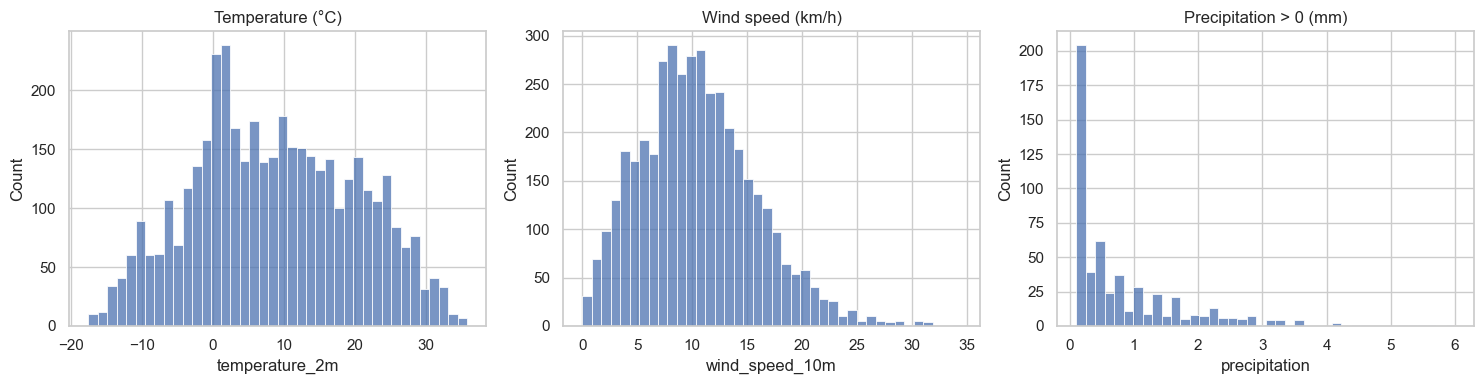

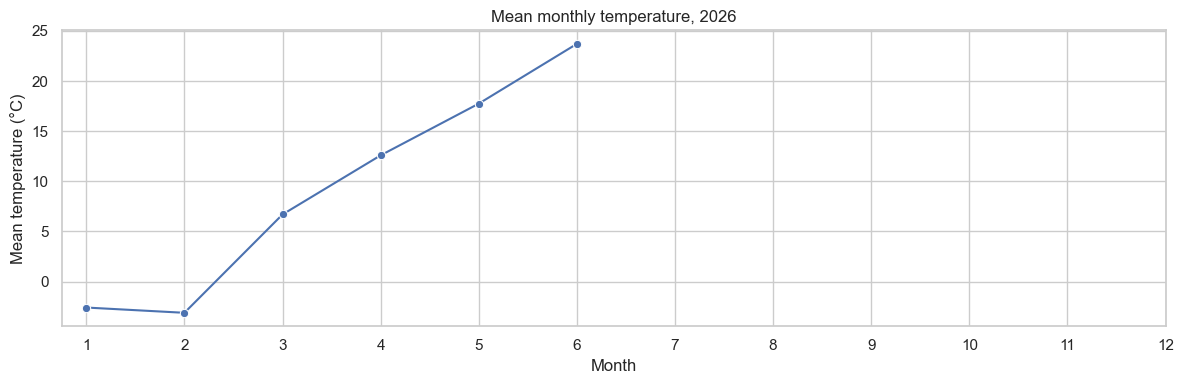

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(weather["temperature_2m"], bins=40, ax=axes[0]).set(title="Temperature (°C)")
sns.histplot(weather["wind_speed_10m"], bins=40, ax=axes[1]).set(title="Wind speed (km/h)")
sns.histplot(weather.loc[weather["precipitation"] > 0, "precipitation"], bins=40, ax=axes[2]).set(
    title="Precipitation > 0 (mm)")
plt.tight_layout()
plt.show()

weather["month"] = weather["datetime"].dt.month
monthly_temp = weather.groupby("month")["temperature_2m"].mean()
plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_temp.index, y=monthly_temp.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean temperature (°C)")
plt.title(f"Mean monthly temperature, {ride_year}")
plt.tight_layout()
plt.show()

Temperature follows the expected annual cycle (cold winters, warm summers), while precipitation is
**zero for most hours** with occasional spikes — a heavily right-skewed variable, which is why the
histogram only shows the non-zero values.

### 2.3 Ridership vs. Weather

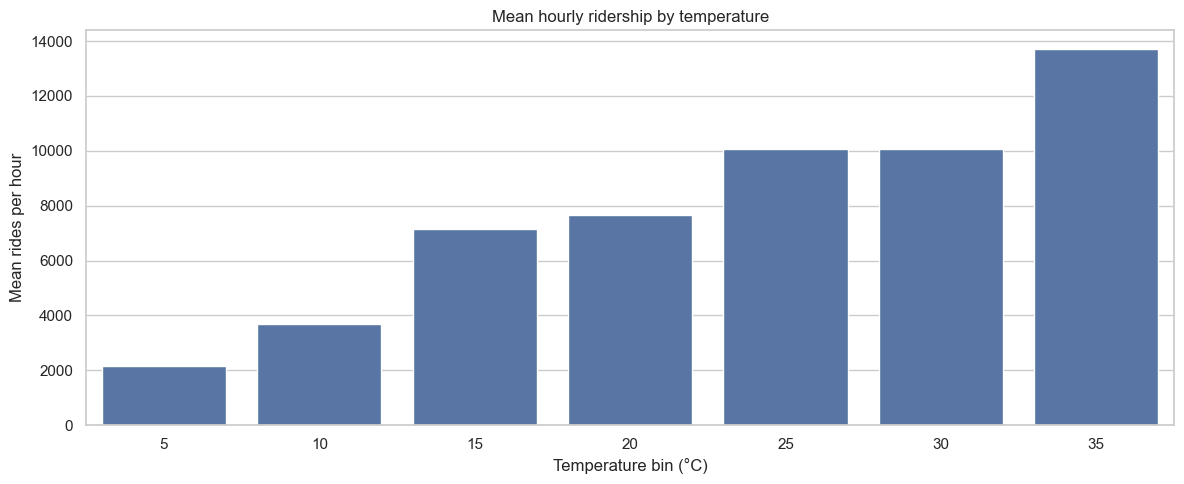

In [44]:
# Join hourly ride counts to the matching weather hour and look at rides vs. temperature.
df["hour_ts"] = df["started_at"].dt.floor("h")
rides_per_hour = df.groupby("hour_ts").size().reset_index(name="rides")
merged = rides_per_hour.merge(weather, left_on="hour_ts", right_on="datetime", how="inner")

merged["temp_bin"] = (merged["temperature_2m"] // 5 * 5).astype(int)
by_temp = merged.groupby("temp_bin")["rides"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="temp_bin", y="rides", data=by_temp)
plt.xlabel("Temperature bin (°C)")
plt.ylabel("Mean rides per hour")
plt.title("Mean hourly ridership by temperature")
plt.tight_layout()
plt.show()

Ridership rises with temperature up to a comfortable range and drops off in the cold — confirming
weather is a useful predictor of demand, which is the main reason this dataset is included.

### 2.4 Data Quality

In [45]:
missing_w = weather.isna().sum()
print("Missing values per column:")
print(missing_w[missing_w > 0] if missing_w.any() else "  none")
print(f"\nHours expected vs. present: "
      f"{int((end_date - start_date).total_seconds() // 3600) + 24} vs. {len(weather)}")

Missing values per column:
  none

Hours expected vs. present: 4152 vs. 4152


## 3. Bike Lanes

NYC's bike-route network from [NYC OpenData](https://data.cityofnewyork.us/) (dataset `mzxg-pwib`),
used to render bike infrastructure. Each row is a route segment with a `the_geom` geometry, the
street, facility class, borough, status and installation/retirement dates.

In [46]:
routes = pd.read_csv(BIKE_ROUTES_URL, low_memory=False)
print("Shape:", routes.shape)
print("Columns:", routes.columns.tolist())
routes.head()

Shape: (28983, 25)
Columns: ['the_geom', 'segmentid', 'bikeid', 'prevbikeid', 'status', 'boro', 'street', 'fromstreet', 'tostreet', 'onoffst', 'facilitycl', 'allclasses', 'bikedir', 'lanecount', 'ft_facilit', 'tf_facilit', 'ft2facilit', 'tf2facilit', 'instdate', 'ret_date', 'grnwy', 'gwsystem', 'gwsys2', 'spur', 'gwyjuris']


,the_geom,segmentid,bikeid,prevbikeid,status,boro,street,fromstreet,tostreet,onoffst,facilitycl,allclasses,bikedir,lanecount,ft_facilit,tf_facilit,ft2facilit,tf2facilit,instdate,ret_date,grnwy,gwsystem,gwsys2,spur,gwyjuris
0,MULTILINESTRING ((-74.192429667502 40.52174149...,2579,6562,NaN,Current,5,HYLAN BLVD,HOLTEN AV,LUTEN AV,ON,II,II,2,2,Curbside Buffered,Curbside Buffered,NaN,NaN,10/01/2007,NaN,Greenway,Staten Island Waterfront,NaN,Main Alignment,NYCDOT
1,MULTILINESTRING ((-74.16031384424598 40.589027...,5033,4272,NaN,Current,5,MERRYMOUNT ST,RICHMOND HILL RD,ROCKLAND AV,ON,II,II,2,2,Conventional Buffered,Conventional Buffered,NaN,NaN,08/12/2021,NaN,NaN,NaN,NaN,NaN,NaN
2,MULTILINESTRING ((-74.12631986979562 40.635252...,10186,2107,NaN,Current,5,CLOVE ROAD,RICHMOND TERR,FOREST AVE,ON,III,III,2,2,Shared,Shared,NaN,NaN,09/11/2015,NaN,NaN,NaN,NaN,NaN,NaN
3,MULTILINESTRING ((-74.00973537112554 40.645666...,20716,942,NaN,Current,3,5 AV,23 ST,50 ST,ON,III,III,2,2,Shared,Shared,NaN,NaN,07/02/2013,NaN,NaN,NaN,NaN,NaN,NaN
4,MULTILINESTRING ((-74.02089492413252 40.626542...,126857,951,NaN,Current,3,6 AVENUE,67 ST,FT HAMILTON PKWY,ON,III,III,2,2,Shared,Shared,NaN,NaN,06/29/2015,NaN,NaN,NaN,NaN,NaN,NaN


### 3.1 Breakdowns

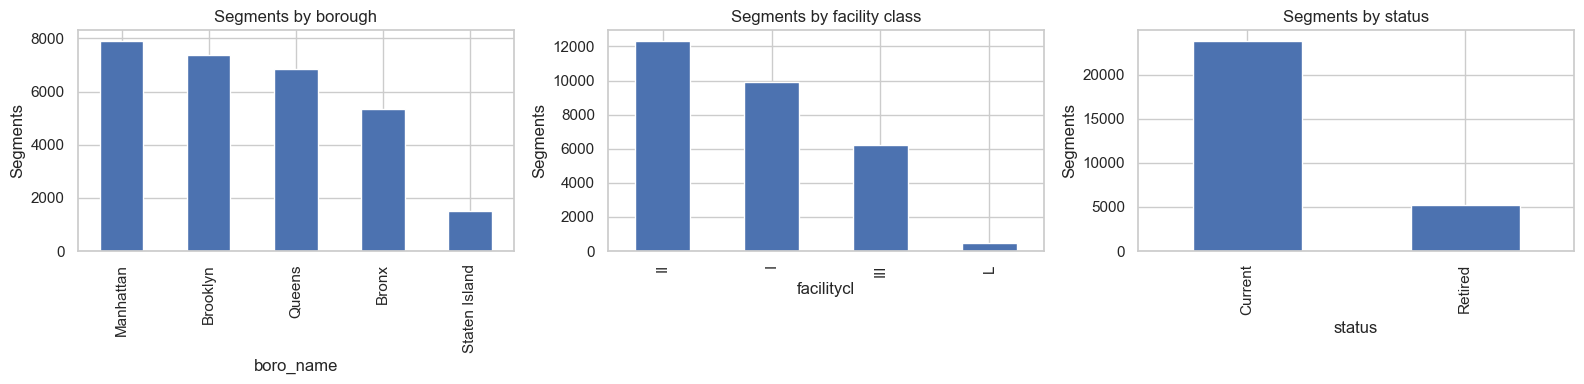

In [47]:
BORO = {1: "Manhattan", 2: "Bronx", 3: "Brooklyn", 4: "Queens", 5: "Staten Island"}
routes["boro_name"] = routes["boro"].map(BORO)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
routes["boro_name"].value_counts().plot.bar(ax=axes[0], title="Segments by borough")
routes["facilitycl"].value_counts().plot.bar(ax=axes[1], title="Segments by facility class")
routes["status"].value_counts().plot.bar(ax=axes[2], title="Segments by status")
for ax in axes:
    ax.set_ylabel("Segments")
plt.tight_layout()
plt.show()

Segments concentrate in Manhattan and Brooklyn, and most are **current** rather than retired. The
facility class encodes the level of protection (e.g. protected paths vs. shared/sharrow lanes),
which matters for how the network is rendered in the visualization.

### 3.2 Installation Timeline

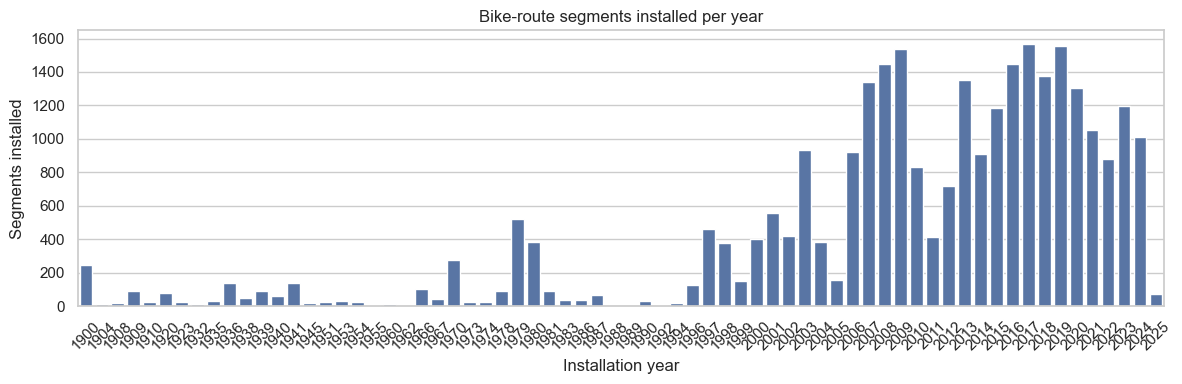

In [48]:
routes["install_year"] = pd.to_datetime(
    routes["instdate"], errors="coerce"
).dt.year
by_year = routes["install_year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.barplot(x=by_year.index.astype(int), y=by_year.values)
plt.xticks(rotation=45)
plt.xlabel("Installation year")
plt.ylabel("Segments installed")
plt.title("Bike-route segments installed per year")
plt.tight_layout()
plt.show()

The installation timeline tracks how NYC's bike network has expanded over the years (note that
`instdate` is missing for some legacy segments, so the earliest years are under-counted).

### 3.3 Map of the Network

In [49]:
# Extract polylines ([[lat, lon], ...]) from a (MULTI)LINESTRING WKT string.
def parse_wkt_lines(wkt):
    if not isinstance(wkt, str):
        return []
    lines = []
    for group in re.findall(r"\(([^()]+)\)", wkt):
        pts = []
        for pair in group.split(","):
            parts = pair.split()
            if len(parts) >= 2:
                lon, lat = float(parts[0]), float(parts[1])  # WKT is lon-lat
                pts.append([lat, lon])
        if pts:
            lines.append(pts)
    return lines

# Draw a sample of segments to keep the map light.
sample = routes.dropna(subset=["the_geom"]).head(800)
routes_map = folium.Map(location=[NYC_LAT, NYC_LON], zoom_start=11)
for geom in sample["the_geom"]:
    for line in parse_wkt_lines(geom):
        folium.PolyLine(line, color="crimson", weight=2, opacity=0.6).add_to(routes_map)
routes_map

### 3.4 Data Quality

In [50]:
quality_cols = ["the_geom", "instdate", "ret_date", "facilitycl", "boro", "street"]
miss = routes[quality_cols].isna().sum()
print("Missing values (selected columns):")
print(pd.DataFrame({"missing": miss, "pct": (miss / len(routes) * 100).round(1)}))
print(f"\nUnmapped borough codes: {routes['boro_name'].isna().sum()}")
print(f"Segments with unparseable installation date: {routes['install_year'].isna().sum()}")

Missing values (selected columns):
            missing   pct
the_geom          0   0.0
instdate          0   0.0
ret_date      23810  82.2
facilitycl        0   0.0
boro              0   0.0
street            0   0.0

Unmapped borough codes: 0
Segments with unparseable installation date: 0


## 4. Station Metadata (GBFS)

Current station information and live availability from the Lyft GBFS feed (the same feed the
backend uses). Two endpoints are merged: `station_information` (static: name, location, capacity)
and `station_status` (live: bikes/docks available, operational flags).

In [51]:
info = requests.get(GBFS_INFO_URL, timeout=(5, 30)).json()["data"]["stations"]
status = requests.get(GBFS_STATUS_URL, timeout=(5, 30)).json()["data"]["stations"]
status_map = {s["station_id"]: s for s in status}

rows = []
for s in info:
    st = status_map.get(s["station_id"], {})
    counts = {v.get("vehicle_type_id"): v.get("count", 0)
              for v in st.get("vehicle_types_available", [])}
    rows.append({
        "station_id": s["station_id"],
        "short_name": s.get("short_name"),
        "name": s.get("name"),
        "lat": s.get("lat"),
        "lon": s.get("lon"),
        "capacity": s.get("capacity"),
        "num_bikes_available": st.get("num_bikes_available"),
        "num_classic": counts.get("1"),
        "num_ebikes": counts.get("2"),
        "num_docks_available": st.get("num_docks_available"),
        "is_installed": st.get("is_installed"),
        "is_renting": st.get("is_renting"),
        "is_returning": st.get("is_returning"),
    })
stations = pd.DataFrame(rows)
stations["active"] = (
    (stations["is_installed"] == 1) & (stations["is_renting"] == 1) & (stations["is_returning"] == 1)
)
print(f"Stations in feed: {len(stations)}  (active: {stations['active'].sum()})")
stations.head()

Stations in feed: 2412  (active: 2342)


,station_id,short_name,name,lat,lon,capacity,num_bikes_available,num_classic,num_ebikes,num_docks_available,is_installed,is_renting,is_returning,active
0,66dd1f44-0aca-11e7-82f6-3863bb44ef7c,5785.05,Greenpoint Ave & Manhattan Ave,40.730260,-73.953940,27,0,0,0,0,0,0,0,False
1,90b141b9-c39f-4a26-a32d-08c7d1474d52,7883.06,Lafayette Ave & Hunts Point Ave,40.816567,-73.888161,22,0,0,0,0,0,0,0,False
2,1795146692060860976,7983.02,Longfellow Ave & Aldus St,40.823194,-73.887629,24,0,0,0,0,0,0,0,False
3,66ddea99-0aca-11e7-82f6-3863bb44ef7c,3762.08,10 St & 7 Ave,40.666208,-73.981999,23,0,0,0,0,0,0,0,False
4,06439006-11b6-44f0-8545-c9d39035f32a,5216.06,Vesey St & Church St,40.712220,-74.010472,78,0,0,0,0,0,0,0,False


### 4.1 Capacity and Live Availability

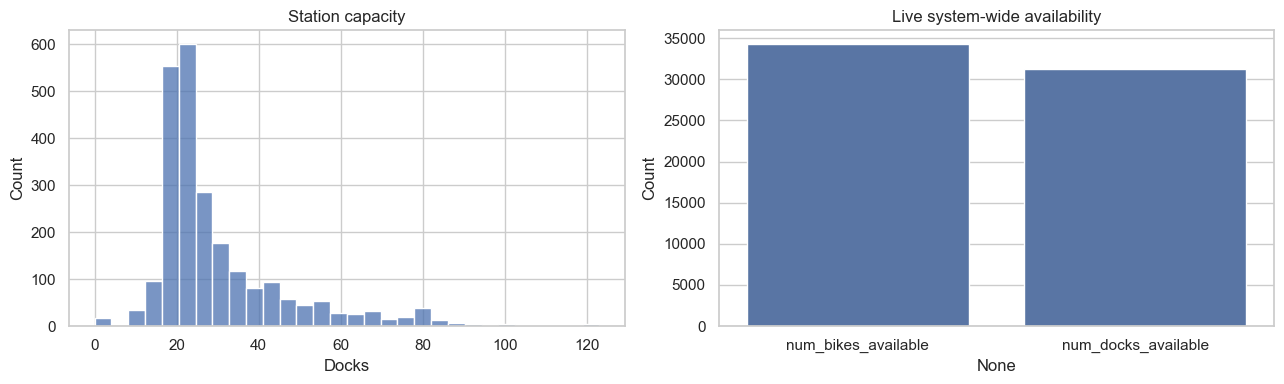

Total bikes available now : 34235
  of which e-bikes        : 14742
Total docks available now : 31214


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(stations["capacity"].dropna(), bins=30, ax=axes[0]).set(
    title="Station capacity", xlabel="Docks")
avail = stations[["num_bikes_available", "num_docks_available"]].sum()
sns.barplot(x=avail.index, y=avail.values, ax=axes[1])
axes[1].set(title="Live system-wide availability", ylabel="Count")
plt.tight_layout()
plt.show()

print(f"Total bikes available now : {int(stations['num_bikes_available'].sum())}")
print(f"  of which e-bikes        : {int(stations['num_ebikes'].sum())}")
print(f"Total docks available now : {int(stations['num_docks_available'].sum())}")

### 4.2 Station Map

In [53]:
station_map = folium.Map(location=[NYC_LAT, NYC_LON], zoom_start=12)
for _, s in stations.dropna(subset=["lat", "lon"]).iterrows():
    folium.CircleMarker(
        [s["lat"], s["lon"]],
        radius=2,
        color="green" if s["active"] else "gray",
        fill=True,
    ).add_to(station_map)
station_map

### 4.3 Data Quality

In [54]:
print(f"Inactive stations (not installed/renting/returning): {(~stations['active']).sum()}")
print(f"Stations missing capacity : {stations['capacity'].isna().sum()}")
print(f"Stations missing coords   : {stations[['lat', 'lon']].isna().any(axis=1).sum()}")

# The numeric station_id (GBFS) differs from the public short_name used in the trip files;
# joins between live stations and historical trips must go through short_name.
print("\nExample station_id vs short_name:")
print(stations[["station_id", "short_name", "name"]].head())

Inactive stations (not installed/renting/returning): 70
Stations missing capacity : 0
Stations missing coords   : 0

Example station_id vs short_name:
                             station_id short_name  \
0  66dd1f44-0aca-11e7-82f6-3863bb44ef7c    5785.05   
1  90b141b9-c39f-4a26-a32d-08c7d1474d52    7883.06   
2                   1795146692060860976    7983.02   
3  66ddea99-0aca-11e7-82f6-3863bb44ef7c    3762.08   
4  06439006-11b6-44f0-8545-c9d39035f32a    5216.06   

                              name  
0   Greenpoint Ave & Manhattan Ave  
1  Lafayette Ave & Hunts Point Ave  
2        Longfellow Ave & Aldus St  
3                    10 St & 7 Ave  
4             Vesey St & Church St  


The numeric `station_id` from GBFS is **not** the identifier used in the historical trip files —
those use the public `short_name`. Any join between live station metadata and trip data must go
through `short_name`. Inactive stations also remain in the feed and are filtered out for live views.